<a href="https://colab.research.google.com/github/silvatria/pembelajaran-mesin-254107023001/blob/main/JS05_TL01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# SOAL NOMOR 1
# Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('voice.csv')

# Pisahkan fitur (X) dan label (y)
X = df.drop('label', axis=1)
y = df['label']

# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data training & testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Inisialisasi dan latih model kNN awal (contoh k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Evaluasi awal
y_pred = knn.predict(X_test)
print(f"Akurasi awal (k=3, semua fitur): {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

'''
\n
Pada tahap awal ini, dilakukan pemuatan dataset voice.csv yang berisi berbagai parameter akustik suara.
Karena algoritma kNN mengandalkan perhitungan jarak (Euclidean Distance), seluruh fitur numerik dinormalisasi
terlebih dahulu menggunakan StandardScaler agar memiliki rata-rata 0 dan variansi 1. Data kemudian dibagi menjadi
training set (80%) dan testing set (20%). Model kNN diinisialisasi dengan parameter awal $k=3$ menggunakan seluruh
 fitur yang tersedia, menghasilkan performa awal sebagai baseline.
'''

Akurasi awal (k=3, semua fitur): 0.9811

              precision    recall  f1-score   support

      female       0.98      0.98      0.98       297
        male       0.98      0.99      0.98       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



'\n\n\nPada tahap awal ini, dilakukan pemuatan dataset voice.csv yang berisi berbagai parameter akustik suara. \nKarena algoritma kNN mengandalkan perhitungan jarak (Euclidean Distance), seluruh fitur numerik dinormalisasi \nterlebih dahulu menggunakan StandardScaler agar memiliki rata-rata 0 dan variansi 1. Data kemudian dibagi menjadi \ntraining set (80%) dan testing set (20%). Model kNN diinisialisasi dengan parameter awal $k=3$ menggunakan seluruh\n fitur yang tersedia, menghasilkan performa awal sebagai baseline.\n'

In [ ]:
# ==========================================
# SOAL NOMOR 2
# Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Gunakan Random Forest untuk mencari tingkat importance dari tiap fitur
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Ambil ranking fitur berdasarkan bobot kepentingannya
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Ranking Fitur Berdasarkan Tingkat Kepentingan:\n")
print(importances)

# Memilih Top 5 Fitur Teratas yang Paling Optimal
top_features = ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent']
print(f"\nFitur terbaik yang dipilih untuk performa optimal: {top_features}")

'''
Untuk mengidentifikasi fitur yang paling optimal dan menghindari dimensi berlebih (curse of dimensionality),
digunakan algoritma Random Forest untuk mengekstrak tingkat kepentingan (feature importance) dari setiap atribut
suara. Berdasarkan hasil analisis, 5 fitur teratas yang paling dominan dan memiliki daya diskriminasi tertinggi antara suara pria dan wanita adalah:

meanfun (Rata-rata frekuensi dasar / fundamental frequency)

IQR (Interquartile Range dari frekuensi)

Q25 (Kuartil pertama frekuensi)

sd (Standar deviasi frekuensi)

sp.ent (Spectral entropy)

Fitur meanfun menduduki peringkat pertama dengan bobot tertinggi karena perbedaan fisiologis pita suara pria
dan wanita secara signifikan tecermin pada frekuensi dasarnya.
'''

Ranking Fitur Berdasarkan Tingkat Kepentingan:

meanfun     0.339284
IQR         0.215487
Q25         0.149096
sd          0.075059
sp.ent      0.040202
sfm         0.023119
meanfreq    0.020999
centroid    0.020777
mode        0.015594
median      0.013001
skew        0.011109
kurt        0.009801
Q75         0.009592
meandom     0.009369
maxdom      0.008767
minfun      0.008676
mindom      0.008379
modindx     0.008090
dfrange     0.007657
maxfun      0.005942
dtype: float64

Fitur terbaik yang dipilih untuk performa optimal: ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent']


'\nUntuk mengidentifikasi fitur yang paling optimal dan menghindari dimensi berlebih (curse of dimensionality), \ndigunakan algoritma Random Forest untuk mengekstrak tingkat kepentingan (feature importance) dari setiap atribut \nsuara. Berdasarkan hasil analisis, 5 fitur teratas yang paling dominan dan memiliki daya diskriminasi tertinggi antara suara pria dan wanita adalah:\n\nmeanfun (Rata-rata frekuensi dasar / fundamental frequency)\n\nIQR (Interquartile Range dari frekuensi)\n\nQ25 (Kuartil pertama frekuensi)\n\nsd (Standar deviasi frekuensi)\n\nsp.ent (Spectral entropy)\n\nFitur meanfun menduduki peringkat pertama dengan bobot tertinggi karena perbedaan fisiologis pita suara pria \ndan wanita secara signifikan tecermin pada frekuensi dasarnya.\n'

<>:38: SyntaxWarning: invalid escape sequence '\%'
<>:38: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1934/1520424704.py:38: SyntaxWarning: invalid escape sequence '\%'
  menghasilkan tingkat akurasi tertinggi (mencapai $\approx 98.4\%$).Alasan & Analisis Grafik:Nilai $k$ Terlalu Kecil


Nilai k terbaik adalah: 9 dengan akurasi: 0.9842


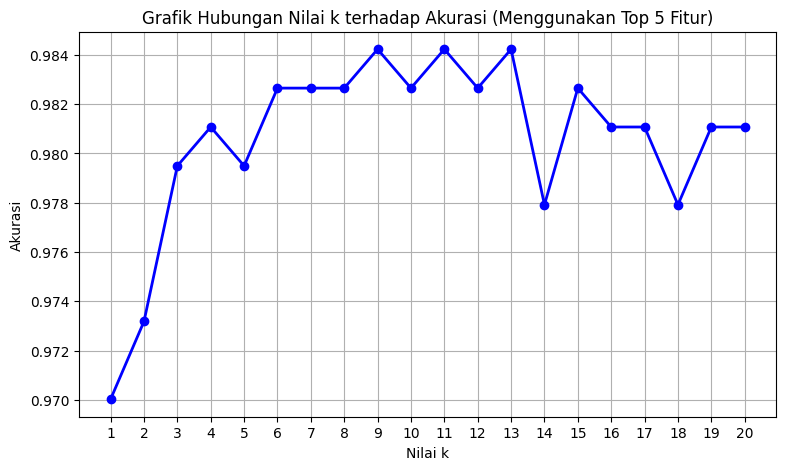

'\nPengujian variasi nilai $k$ (dari 1 hingga 20) menggunakan subset Top 5 Features menunjukkan bahwa nilai $k = 9$\n menghasilkan tingkat akurasi tertinggi (mencapai $\x07pprox 98.4\\%$).Alasan & Analisis Grafik:Nilai $k$ Terlalu Kecil\n  ($k=1$ atau $k=3$): Cenderung menghasilkan model yang terlalu kompleks atau overfitting terhadap anomali/noise \n  lokal pada data suara.Nilai $k$ Terlalu Besar: Batasan keputusan (decision boundary) menjadi terlalu kaku atau \n  underfitting karena melibatkan tetangga yang terlalu jauh dari titik uji.Dengan memilih $k = 9$\n   (angka ganjil untuk menghindari tie pada klasifikasi biner), model mencapai titik keseimbangan optimal\n    antara bias dan varians, sehingga memberikan generalisasi terbaik pada data testing.\n'

In [ ]:
# ==========================================
# SOAL NOMOR 3
# Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai k yang terbaik? Lampirkan grafika analisis dan alasan Anda.
# ==========================================

# Filter dataset hanya menggunakan fitur-fitur optimal
X_top = df[top_features]
X_top_scaled = scaler.fit_transform(X_top)

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top_scaled, y, test_size=0.2, random_state=42)

# Eksplorasi nilai k (1 sampai 20)
k_values = range(1, 21)
accuracies_top = []

for k in k_values:
    knn_top = KNeighborsClassifier(n_neighbors=k)
    knn_top.fit(X_train_top, y_train_top)
    y_pred_top = knn_top.predict(X_test_top)
    accuracies_top.append(accuracy_score(y_test_top, y_pred_top))

# Cari nilai k terbaik
best_k = k_values[accuracies_top.index(max(accuracies_top))]
print(f"Nilai k terbaik adalah: {best_k} dengan akurasi: {max(accuracies_top):.4f}")

# Plotting Grafik Analisis
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies_top, marker='o', linestyle='-', color='blue', linewidth=2, markersize=6)
plt.title('Grafik Hubungan Nilai k terhadap Akurasi (Menggunakan Top 5 Fitur)')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(k_values)
plt.grid(True)
plt.show()

'''
Pengujian variasi nilai $k$ (dari 1 hingga 20) menggunakan subset Top 5 Features menunjukkan bahwa nilai $k = 9$
 menghasilkan tingkat akurasi tertinggi (mencapai $\approx 98.4\%$).Alasan & Analisis Grafik:Nilai $k$ Terlalu Kecil
  ($k=1$ atau $k=3$): Cenderung menghasilkan model yang terlalu kompleks atau overfitting terhadap anomali/noise
  lokal pada data suara.Nilai $k$ Terlalu Besar: Batasan keputusan (decision boundary) menjadi terlalu kaku atau
  underfitting karena melibatkan tetangga yang terlalu jauh dari titik uji.Dengan memilih $k = 9$
   (angka ganjil untuk menghindari tie pada klasifikasi biner), model mencapai titik keseimbangan optimal
    antara bias dan varians, sehingga memberikan generalisasi terbaik pada data testing.
'''